# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

Use `pandas`, `numpy`, `seaborn`, `matplotlib`, and `scikit-learn`. Do **not** use scikit-learn pipelines for this assignment. Use ordinary data frames, `pd.get_dummies`, and `LinearRegression` so that every column in the model is visible and interpretable.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Check that `brand_share` sums to 1 within each year.
3. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
4. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
5. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [75]:
# imports needed for project
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import sklearn as sk
from sklearn.linear_model import LinearRegression 

In [94]:
# Q1.1

df = pd.read_csv('air_fryers_clean_brand_year.csv')
df.head()

# product characteristics are 'compact_share', 'dual_basket_share', 'oven_style_share', 
# 'rotisserie_share', and 'window_share' 

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [77]:
# Q1.1

df['brand'].nunique() #10 unique values in brand column

10

In [78]:
# Q1.1

df['year'].unique() # unique values in year column are 2019, 2020, 2021, 2022, and 2023

array([2019, 2020, 2021, 2022, 2023])

In [79]:
# Q1.2
df.groupby('year')['brand_share'].sum() #each year does in fact sum to 1 in the brand_share column

year
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
Name: brand_share, dtype: float64

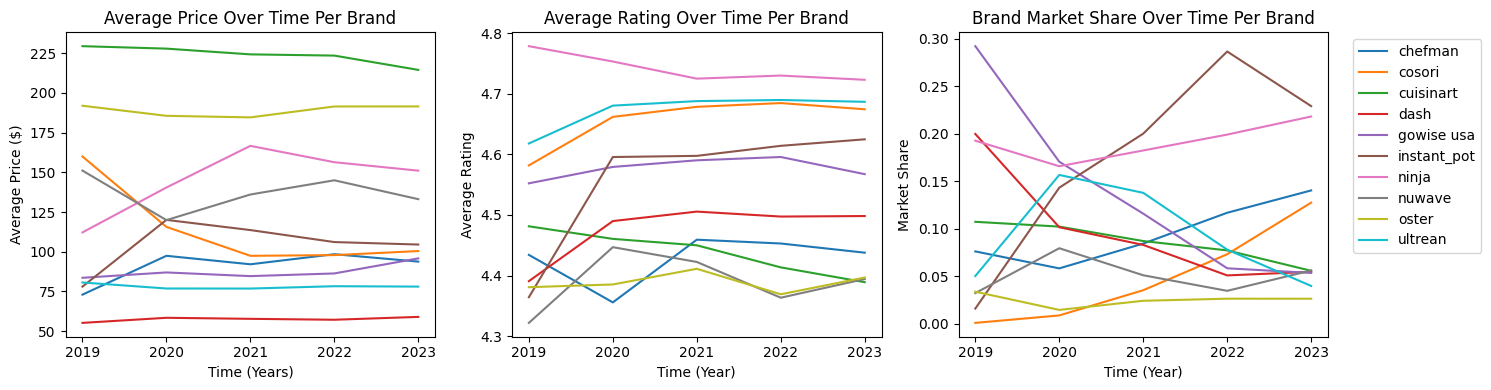

In [80]:
# Q1.3 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=df, x='year', y='avg_price', hue='brand', legend=False, ax=axes[0]).set(title='Average Price Over Time Per Brand', xlabel='Time (Years)', ylabel='Average Price ($)')
sns.lineplot(df, x = 'year', y = 'avg_rating', hue = 'brand' , legend=False, ax=axes[1]).set(title='Average Rating Over Time Per Brand', xlabel='Time (Year)', ylabel='Average Rating')
sns.lineplot(df, x = 'year', y = 'brand_share', hue = 'brand' , ax=axes[2]).set(title='Brand Market Share Over Time Per Brand', xlabel='Time (Year)', ylabel='Market Share')
axes[2].legend(loc='upper left', bbox_to_anchor=(1.05, 1), ncol=1)
plt.tight_layout()
plt.show()



In [ ]:
# 1.4
for i in df.columns:
    print(df[i].value_counts())

category
air_fryers    50
Name: count, dtype: int64
year
2019    10
2020    10
2021    10
2022    10
2023    10
Name: count, dtype: int64
brand
chefman        5
cosori         5
cuisinart      5
dash           5
gowise usa     5
instant_pot    5
ninja          5
nuwave         5
oster          5
ultrean        5
Name: count, dtype: int64
purchase_count
1146    1
11      1
1616    1
3011    1
4405    1
238     1
2904    1
484     1
506     1
755     1
1761    1
260     1
3094    1
3074    1
5164    1
4336    1
5020    1
2404    1
436     1
4742    1
2600    1
1084    1
2682    1
2556    1
3572    1
6172    1
5625    1
1570    1
741     1
4248    1
2752    1
1722    1
1817    1
1196    1
1373    1
6756    1
4693    1
813     1
618     1
1836    1
1178    1
1070    1
467     1
458     1
448     1
1924    1
1832    1
470     1
220     1
333     1
Name: count, dtype: int64
product_count
9     4
10    3
5     3
22    2
19    2
14    2
33    2
16    2
31    2
12    2
6     2
2     1
45    1
1

From this we can see that there are 5 products from each of the brands (therefore 50 products total, 50 rows) because there are 5 years of years of data from 10 different brands. The purchase counts, product counts, average_price, average rating, compact share, oven style share, brand share, and log brand share vary almost completely. The market purchases and number of products per year are both evenly 10 rows per the 5 unique values in those respective columns. This is likely related to the 10 brands (i.e. there is a product from each brand every year, and for every marketpurchase value). Additionally, in both window share and dual basket share there are 41 rows with a value of 0.0. Lastly, rotisserie share has 27 rows of value 0.0

In [82]:
# 1.5

print(f"average price per brand: {df.groupby(["brand"])['avg_price'].mean()}")

eda_df = pd.concat([df.groupby(["brand"])['compact_share'].mean(), df.groupby(["brand"])['dual_basket_share'].mean(), df.groupby(["brand"])['oven_style_share'].mean(),
          df.groupby(["brand"])['rotisserie_share'].mean(), df.groupby(["brand"])['window_share'].mean(), df.groupby(["brand"])['brand_share'].mean()], axis = 1)

eda_df

average price per brand: brand
chefman         90.938411
cosori         114.267950
cuisinart      223.947093
dash            57.478927
gowise usa      87.454781
instant_pot    104.461353
ninja          145.342541
nuwave         137.024384
oster          189.031284
ultrean         78.114606
Name: avg_price, dtype: float64


,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,brand_share
brand,,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081,0.095079
cosori,0.996784,0.000000,0.029952,0.024076,0.000000,0.048974
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000,0.085787
dash,0.999481,0.000000,0.890098,0.000000,0.000000,0.097862
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320,0.138005
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012,0.174921
ninja,0.992084,0.002488,0.100477,0.000000,0.000000,0.191567
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000,0.050559
oster,1.000000,0.000000,0.864518,0.000000,0.000000,0.024876


### 1.5. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time? <br>
The brands that are most expensive are cuisinert, oster, and ninja. The brands with the largest shares are instant pot, ninja, and gowise usa. From the plot above in part 3 shows that brands such as cuisinart, oster, ultrean, dash, and gowise usa have a relatively stable market price from 2019 to 2023, whereas brands such as ninja, cosori, instant pot, nuwave, and chefman fluxuate over time. 

## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$?
2. Is it negative? Why is that important?
3. Which product features are associated with higher demand?
4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.
5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.
6. What is the model's $R^2$?

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

In [83]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

feature_cols = ["compact_share", "dual_basket_share", "oven_style_share", "rotisserie_share", "window_share"]
x_dum = pd.get_dummies(df.loc[:, ['brand', 'year']], columns = ['brand', 'year'], dtype = 'int', drop_first = True)
y = df['log_brand_share']

X = pd.concat([df[["avg_price", "avg_rating"] + feature_cols], x_dum], axis = 1,)

linreg = LinearRegression()
linreg = linreg.fit(X, y)


linreg_table = pd.DataFrame({"feature": X.columns, "coefficient": linreg.coef_})
linreg_table

,feature,coefficient
0,avg_price,-0.037668
1,avg_rating,0.287517
2,compact_share,9.815304
3,dual_basket_share,-9.509686
4,oven_style_share,1.941774
5,rotisserie_share,-5.674054
6,window_share,12.880298
7,brand_cosori,2.551946
8,brand_cuisinart,6.422436
9,brand_dash,0.176655


In [84]:
print(f"price coefficient: {linreg.coef_[0]}")



price coefficient: -0.03766765298429363


In [85]:
pred = linreg.predict(X)
r2 = r2_score(y, pred)
print(f"r squared: {r2}")

r squared: 0.7634539500914361


### 1. What is the estimated price coefficient, $\hat{\beta}_{price}$?
The estimated price coefficient is ~ -0.0372. This means that as we increase by $1, the log brand share decreases by 0.0372 
### 2. Is it negative? Why is that important?
It is negative, and this shows that brand shares are decreasing as price increases, so brands should be very deliberate and careful when increasing their prices. 

### 3. Which product features are associated with higher demand?
Window share and compact share have a positive and the highest coefficients by far. This indicates that increasing the feature, or in this case simply having a window and or it being compact, would increase the demand relative to the baseline. 

### 4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.

Cuisinart and ninja have the largest coefficients/the highest predicted log brand share relative to the baseline which is chefman. Their mean log brand share is higher than chefman’s by the amount of their coefficients.

### 5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.

The year 2020 have the largest coefficient/the highest predicted log brand share relative to the baseline which is 2019. Their mean log brand share is higher than 2019's by the amount of their coefficients.

### 6. What is the model's $R^2$?

The R^2 is 0.7634539500914361 which means that 76% of the variation in log brand share can be explained by differences between brands and differences between years. 

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

In [ ]:
price_coef = linreg_table.loc[linreg_table["feature"] == "avg_price", "coefficient"].iloc[0]
print("estimated price coefficient:", price_coef) 

q3_df = pd.DataFrame()

q3_df['year'] = df['year']
q3_df['brand'] = df['brand']
q3_df['avg_rating'] = df['avg_rating']
q3_df['avg_price'] = df['avg_price']
q3_df['brand_share'] = df['brand_share']

q3_df["predicted_log_share"] = pred
q3_df["demand_slope"] = price_coef*df["brand_share"] * (1 - df["brand_share"])
q3_df["unit_cost"] = df["avg_price"] + df["brand_share"] / q3_df["demand_slope"]
q3_df["markup"] = df["avg_price"] - q3_df["unit_cost"]
q3_df["avg_profit"] = df["brand_share"]*q3_df["markup"]

q3_df.head()

estimated price coefficient: -0.03766765298429363


,year,brand,avg_rating,avg_price,brand_share,predicted_log_share,demand_slope,unit_cost,markup,avg_profit,profit_derivative
0,2019,chefman,4.434119,72.963695,0.076015,-2.456470,-0.002646,44.231656,28.732039,2.184062,0.000000e+00
1,2019,cosori,4.581818,159.990000,0.000730,-5.986038,-0.000027,133.422638,26.567362,0.019385,1.084202e-19
2,2019,cuisinart,4.481312,229.465274,0.107190,-2.754965,-0.003605,199.729962,29.735313,3.187335,5.551115e-17
3,2019,dash,4.390767,55.176333,0.199721,-2.238693,-0.006021,22.002913,33.173420,6.625442,0.000000e+00
4,2019,gowise usa,4.552259,83.575551,0.292186,-1.869862,-0.007790,46.068541,37.507010,10.959033,0.000000e+00


### 1. What are the average unit costs and markups for each brand over the years?


In [87]:
q3_df.groupby('year')['unit_cost'].mean()

year
2019    91.660064
2020    93.302709
2021    93.776068
2022    94.298312
2023    92.474045
Name: unit_cost, dtype: float64

In [88]:
q3_df.groupby('year')['markup'].mean()

year
2019    29.841683
2020    29.613533
2021    29.616830
2022    29.752366
2023    29.695055
Name: markup, dtype: float64

### 2. Are any inferred unit costs negative? If so, what might that mean?
No, none are negative, but if it were then I would be concerned over faults in the computations or data cleaning to see if there a mistake in the evaluation of the unit cost. 

### 3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost. Do more expensive products have higher consumer satisfaction?

In [89]:
q3_df.groupby('brand')['unit_cost'].mean().sort_values(ascending=False) # Cuisinart has the highest average unit costs

brand
cuisinart      194.896119
oster          161.804969
ninja          112.488470
nuwave         109.053549
cosori          86.283321
instant_pot     71.903119
chefman         61.569466
gowise usa      56.301040
ultrean         48.785765
dash            27.936578
Name: unit_cost, dtype: float64

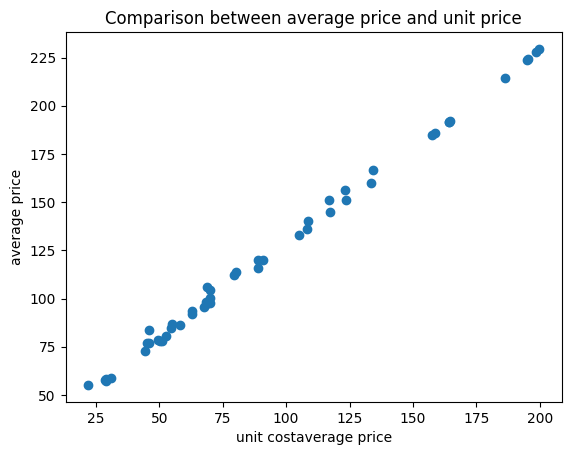

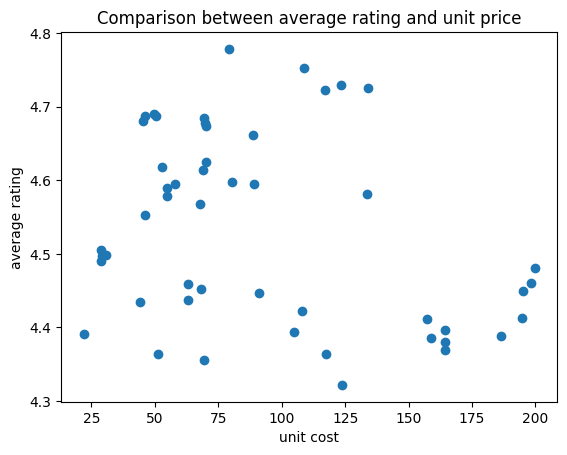

In [90]:
#q3_df.groupby('brand')[['unit_cost', 'avg_rating']].mean()
import matplotlib.pyplot as plt

plt.scatter(data = q3_df, x = 'unit_cost', y = 'avg_price')
plt.title('Comparison between average price and unit price')
plt.xlabel('unit costaverage price')
plt.ylabel('average price')
plt.show()
plt.scatter(data = q3_df, x = 'unit_cost', y = 'avg_rating')
plt.title('Comparison between average rating and unit price')
plt.xlabel('unit cost')
plt.ylabel('average rating')
plt.show()


As shown in the graphs above, there is obviously a strong correlation between average price and unit cost, and this is because unit cost is a component in calculating average price (df["avg_price"] + df["brand_share"] / q3_df["demand_slope"]). Now looking at the scatter plot comparing unit cost with average cost is much more scattered and there is no strong positive or negative correlation. This means that there is no indicator that the unit cost effects the average rating of the product. However, it is important to notice that when unit prices reach 150+, the rating remain relatively low, showing that more expensive products do not generally receive higher satisfaction. 

### 4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.


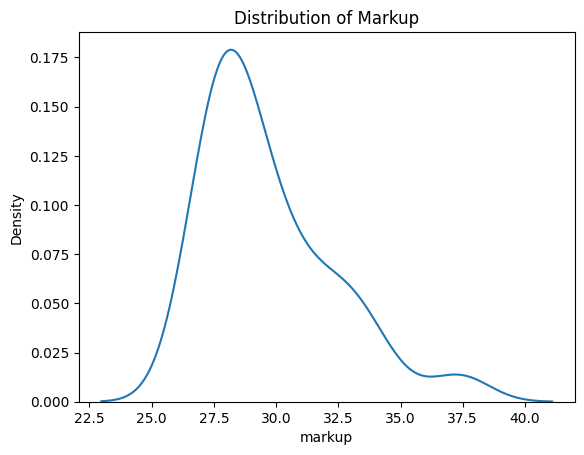

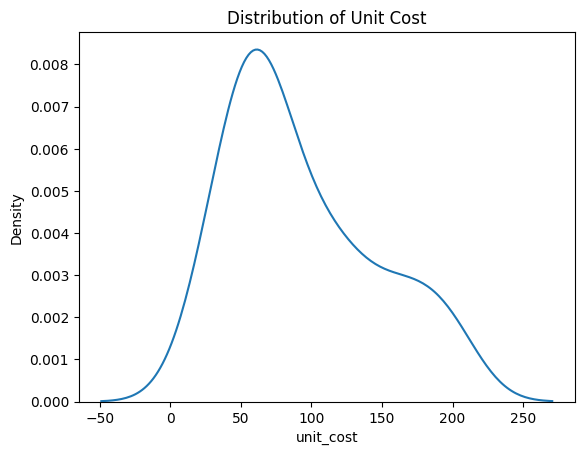

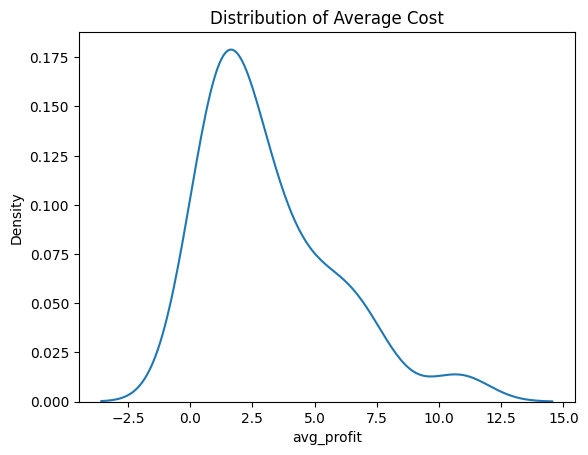

In [91]:
sns.kdeplot(data=q3_df, x='markup')
plt.title('Distribution of Markup')
plt.show()
sns.kdeplot(data=q3_df, x='unit_cost')
plt.title('Distribution of Unit Cost')
plt.show()
sns.kdeplot(data=q3_df, x='avg_profit')
plt.title('Distribution of Average Cost')
plt.show()

In [99]:
print(q3_df['unit_cost'].mean())
print(q3_df['markup'].mean())
print(q3_df['demand_slope'].mean())

93.10223941369206
29.70389350570044
-0.0031948970771344173


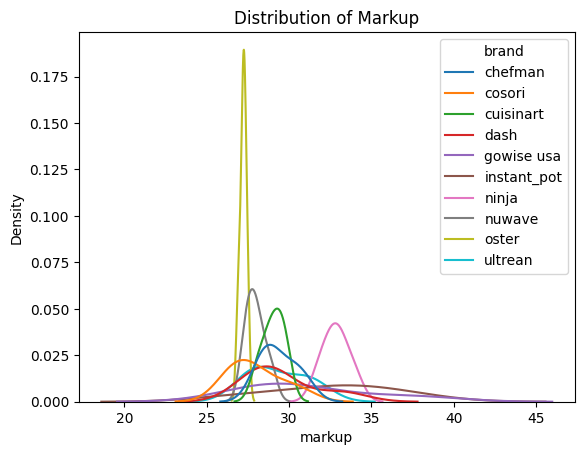

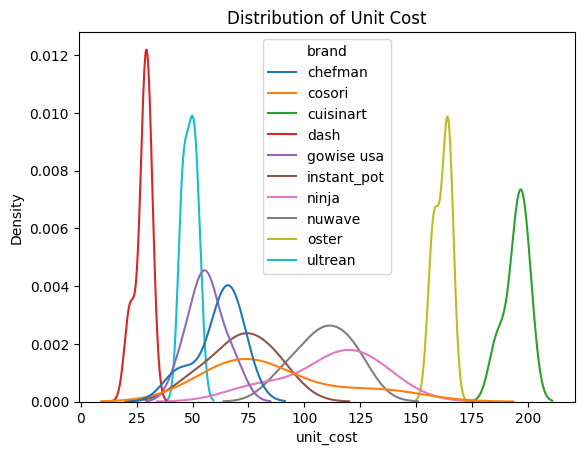

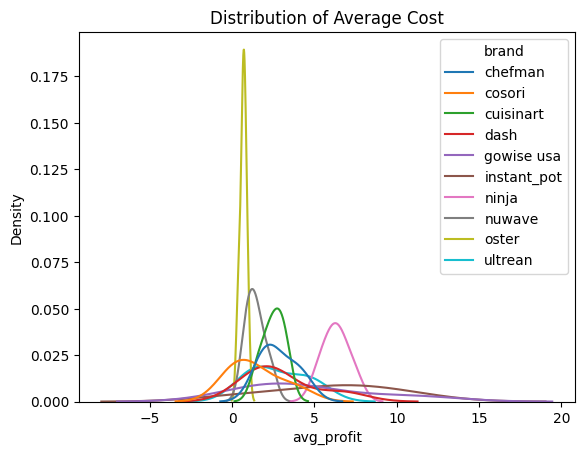

In [92]:
sns.kdeplot(data=q3_df, x='markup', hue = 'brand')
plt.title('Distribution of Markup')
plt.show()
sns.kdeplot(data=q3_df, x='unit_cost',hue = 'brand')
plt.title('Distribution of Unit Cost')
plt.show()
sns.kdeplot(data=q3_df, x='avg_profit', hue = 'brand')
plt.title('Distribution of Average Cost')
plt.show()


### 5. Which brands have the highest share-weighted average profit?



In [93]:
q3_df['weighted_profit'] = q3_df['avg_profit'] * q3_df['brand_share']

q3_df.groupby('brand')['weighted_profit'].sum() #highest share-weighted average profit is instant_pot


brand
chefman        1.484022
cosori         0.682395
cuisinart      1.127636
dash           1.981680
gowise usa     4.710117
instant_pot    6.832246
ninja          6.101823
nuwave         0.403079
oster          0.089652
ultrean        1.643270
Name: weighted_profit, dtype: float64

## 4. Results

Submit a GitHub repo containing:

1. A notebook corresponding to the data analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
2. A notebook corresponding to the data scientist work, including the code and graphs, explicitly answering the questions above in text markdown chunks
3. A notebook corresponding to the pricing analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
4. A short presentation of your findings, about 5-8 slides.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model (multinomial logistic regression, estimated by linear regression on log market share)
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion about the brands' relative positions in the market

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.